In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
import seaborn as sns

In [2]:
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 60.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
from google.colab import drive
drive.mount ('/content/gdrive')

Mounted at /content/gdrive


In [7]:
short_tanea_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/TA NEA/short_tanea_df.csv')
short_tanea_df

,date,full_text,year,month,day,hour
0,2026-06-09 16:39:00,Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλ...,2026,6,9,16
1,2026-06-07 16:38:00,Έντονους κραδασμούς στο κυβερνητικό στρατόπεδο...,2026,6,7,16
2,2026-06-04 13:20:00,Για τηστάση της κυβέρνησης μπροστά στο αίτημα ...,2026,6,4,13
3,2026-06-04 12:24:00,Νέα δεδομένα στηνπολύκροτη υπόθεση των τηλεφων...,2026,6,4,12
4,2026-06-02 17:03:00,Αίτημαγια ακρόαση τωνΤαλ ΝτίλιανκαιΓρηγόρη Δημ...,2026,6,2,17
...,...,...,...,...,...,...
136,2025-10-22 17:47:00,Μετά την ολοκλήρωση της κατάθεσης του στη δίκη...,2025,10,22,17
137,2025-08-24 18:27:00,Μια νέα τεχνολογία υποκλοπής φέρνει στο προσκή...,2025,8,24,18
138,2025-07-22 12:04:00,Στο δικαστικό προσκήνιο επανέρχεται η υπόθεση ...,2025,7,22,12
139,2025-02-11 14:28:00,Με το σκεπτικό ότι η υπόθεση των τηλεφωνικών υ...,2025,2,11,14


In [9]:
nlp = spacy.load('el_core_news_sm')

In [10]:
text = short_tanea_df['full_text'].str.cat(sep = ' ')

In [ ]:
#Πρώτη προσπάθεια για wordcloud για να πάρουμε μια γενική εικόνα
wordcloud1 = WordCloud(
    stopwords = nlp.Defaults.stop_words,
    width = 2000,
    height = 1000,
    background_color = 'black'
 ).generate(text)
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud1, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
full_doc =nlp(text)
full_doc [:500]

Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλώσεις του υπουργού Δικαιοσύνης Γιώργου Φλωρίδη(«Παραπολιτικά») για την υπόθεση των παρακολουθήσεων ασκεί σε δήλωσή του ο εκπρόσωπος Τύπου του ΠΑΣΟΚ Κώστας Τσουκαλάς.
Ο υπουργός ανέφερε ότι«η δικαιοσύνη κατέληξε σε ποινικές ευθύνες ιδιωτών. Εκείνο το πόρισμα έκρινε ότι δεν υπάρχει εμπλοκή κρατικών υπηρεσιών. Όποιος νομίζει ότι έχει κάτι άλλο, η Δικαιοσύνη είναι εκεί και περιμένει», τονίζει ο κ. Τσουκαλάς, διερωτώμενοςαν ο υπουργός γνωρίζει ότι η υπόθεσηαρχειοθετήθηκε παρά την ύπαρξη νέων στοιχείων που προέκυψαν από το Μονομελές Πλημμελειοδικείο.
Διαβάστε επίσης: Σκάνδαλο υποκλοπών: Τα «κρυφά χαρτιά» του Ντίλιαν
Παράλληλα, θέτει το ερώτημα γιατί δεν κλήθηκε από τις δικαστικές αρχές ο κ. Ντίλιαν, ο οποίος, όπως αναφέρει, από την επομένη της καταδίκης του δηλώνει δημόσια ότι το κατασκοπευτικό λογισμικό πωλήθηκε και χρησιμοποιήθηκε από κρατικές αρχές. Αντιθέτως, σημειώνει, ο κ. Τζαβέλλας ως επισπεύδων κράτησε την υπόθεση στο αρχείο.
Όσο η κυβέρν

In [ ]:
#Lemmatization
lemmatized_text = ' '.join(token.lemma_ for token in full_doc)

In [ ]:
# Re-process the lemmatized_text to filter out verbs directly
doc_for_filtering_verbs = nlp(lemmatized_text)
verb_free_lemmatized_text = ' '.join(token.text for token in doc_for_filtering_verbs if token.pos_ != 'VERB')

wordcloud2 = WordCloud(
    stopwords = nlp.Defaults.stop_words, # Use original stopwords; verbs are filtered from the text itself
    width = 2000,
    height = 1000,
    background_color = 'black'
 ).generate(verb_free_lemmatized_text) # Use the text without verbs
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud2, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('tanea_wordcloud.png')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#Vectorization

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
cv = CountVectorizer()

In [13]:
count_vector = cv.fit_transform(short_tanea_df['full_text'])

In [14]:
count_vector.shape

(141, 10843)

In [15]:
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,00,000,01,02,04,06,09,10,100,10u,...,ύστατη,ύστερα,ύφεση,ύφος,ύψος,ύψους,ώρα,ώραμετά,ώρες,ώστε
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Vectorizer με stop words και όρια στις συχνότητες εμφάνισης των λέξεων

In [ ]:
cv = CountVectorizer(stop_words= list(nlp.Defaults.stop_words), min_df=0.01, max_df=0.95)

In [ ]:
count_vector = cv.fit_transform(short_tanea_df['full_text'])

In [ ]:
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())

results.head()

,00,000,04,10,100,11,12,120,126,12η,...,όφελος,όχημα,όψει,ύλης,ύπαρξη,ύφος,ύψος,ύψους,ώρα,ώρες
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Vectorizer με stop words και token pattern

In [ ]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), token_pattern = '\\bκυβ[α-ωά-ώ]*\\b')
count_vector = cv.fit_transform(short_tanea_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,κυβέρνησή,κυβέρνησής,κυβέρνησε,κυβέρνηση,κυβέρνησηεξαπέλυσε,κυβέρνησημε,κυβέρνησημετά,κυβέρνησης,κυβέρνησηςκαι,κυβέρνησηςμέσω,...,κυβερνητικού,κυβερνητικούς,κυβερνητικό,κυβερνητικός,κυβερνητικών,κυβερνοάμυνας,κυβερνοεπιχειρήσεις,κυβερνοπαρακολούθησης,κυβερνών,κυβερνώντες
0,0,0,0,2,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Vectorizer με ngrams

In [16]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), max_features=25, ngram_range=(2, 2))
count_vector = cv.fit_transform(short_tanea_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,απόφαση μονομελούς,αρείου πάγου,εθνική ασφάλεια,εθνικής ασφάλειας,εισαγγελέα αρείου,εισαγγελέας αρείου,εξεταστική επιτροπή,εξεταστικής επιτροπής,θεσμών διαφάνειας,κατασκοπευτικού λογισμικού,...,νέας δημοκρατίας,νίκος ανδρουλάκης,παράνομων παρακολουθήσεων,πλημμελειοδικείου αθηνών,πρόεδρος πασοκ,σκάνδαλο υποκλοπών,ταλ ντίλιαν,τηλεφωνικών υποκλοπών,υπόθεση τηλεφωνικών,υπόθεση υποκλοπών
0,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,2
1,0,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,2,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,2,2,1,0,0,0,0,0,1,...,0,0,0,0,0,0,5,0,1,0
4,0,0,0,0,0,0,0,2,5,0,...,3,0,2,0,0,0,3,0,0,1


In [24]:
word_counts = results.sum(axis=0).sort_values(ascending=False)
word_counts

,0
αρείου πάγου,161
μονομελούς πλημμελειοδικείου,59
υπόθεση υποκλοπών,50
νίκος ανδρουλάκης,48
πρόεδρος πασοκ,48
θεσμών διαφάνειας,47
κράτους δικαίου,44
κράτος δικαίου,43
εισαγγελέα αρείου,40
τηλεφωνικών υποκλοπών,40


/tmp/ipykernel_6928/127273410.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_words.values, y=top_words.index, palette='viridis')


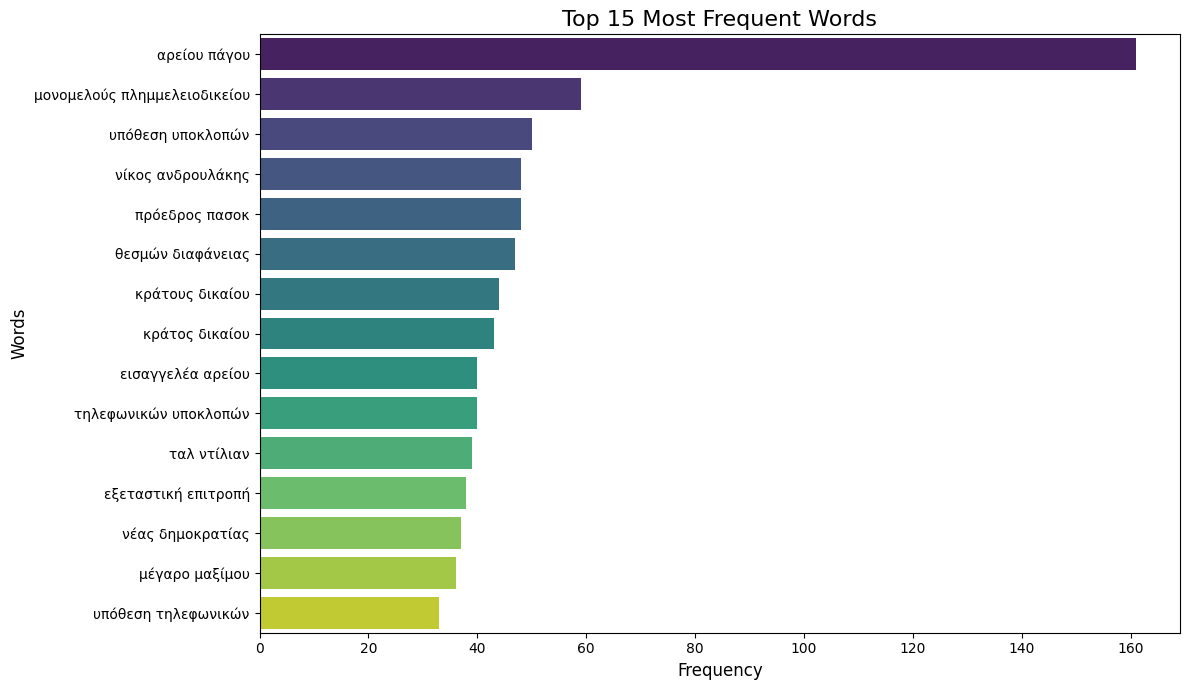

In [22]:
word_counts = results.sum(axis=0).sort_values(ascending=False)

# Select the top 15 words for visualization
top_words = word_counts.head(15)

# Create a horizontal bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=top_words.values, y=top_words.index, palette='viridis')
plt.title('Top 15 Most Frequent Words', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()
plt.savefig ('ngram_tanea.png')
plt.show()

Vectorizer με χρήση λεξικού

In [25]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), max_features=20,
                     vocabulary = ['κατασκοπευτικό', 'κυβέρνηση', 'ντίλιαν', 'συγκάλυψη', 'παράνομες'])
count_vector = cv.fit_transform(short_tanea_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()
print(results.sum(axis=0))

κατασκοπευτικό     22
κυβέρνηση         180
ντίλιαν           103
συγκάλυψη          24
παράνομες          14
dtype: int64


#TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words= list(nlp.Defaults.stop_words), max_features=500)
tfidf_matrix_train = tfidf_vectorizer.fit_transform(short_tanea_df['full_text'])

In [ ]:
results = pd.DataFrame(tfidf_matrix_train.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
results.head()

,120,2020,2021,2022,2023,2026,43,in,intellexa,krikel,...,χθες,χρήση,χρειάζεται,χρόνια,χρόνο,χώρα,χώρας,χώρες,ύπαρξη,ώρα
0,0.0,0.000000,0.0,0.051276,0.0,0.0,0.0,0.0,0.048335,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.062787,0.054702
1,0.0,0.213226,0.0,0.000000,0.0,0.0,0.0,0.0,0.045102,0.0,...,0.0,0.159746,0.0,0.0,0.000000,0.0,0.000000,0.0,0.058588,0.000000
2,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.236547,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.102929,0.0,0.000000,0.053542
4,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.039724,0.0,0.000000,0.0,0.000000,0.000000



#Cosine similarity (ομοιότητα κειμένων)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("cosine scores ==> ",cosine_similarity(tfidf_matrix_train[0:1], tfidf_matrix_train))

cosine scores ==>  [[1.         0.24297445 0.23941327 0.17310422 0.14142233 0.23097947
  0.24309291 0.3460376  0.1243696  0.16675278 0.34093234 0.09069885
  0.18420408 0.04310545 0.16820869 0.13022588 0.05111637 0.05289223
  0.06135591 0.0531548  0.03946855 0.18797969 0.1078062  0.08576167
  0.09957061 0.07497398 0.1631616  0.15223953 0.1742658  0.29800927
  0.17993249 0.23983457 0.21975312 0.07503199 0.20761336 0.03475476
  0.14169876 0.06771025 0.12885188 0.07239803 0.17434076 0.16955358
  0.12918648 0.14833917 0.11278784 0.18282883 0.1217869  0.23094151
  0.17750568 0.19841421 0.07069946 0.23726691 0.04405427 0.00653183
  0.23579276 0.2875163  0.17059176 0.28324421 0.25568103 0.16183709
  0.12738128 0.1185476  0.09782231 0.11898134 0.14370844 0.09575768
  0.16403404 0.15011194 0.18868832 0.16107305 0.11357577 0.13740431
  0.15369303 0.1264891  0.09985562 0.10665158 0.20801144 0.09129187
  0.13664176 0.19770217 0.09787433 0.13800757 0.09586251 0.12870903
  0.0880116  0.16071259 0.313

In [ ]:
arr = cosine_similarity(tfidf_matrix_train, tfidf_matrix_train)

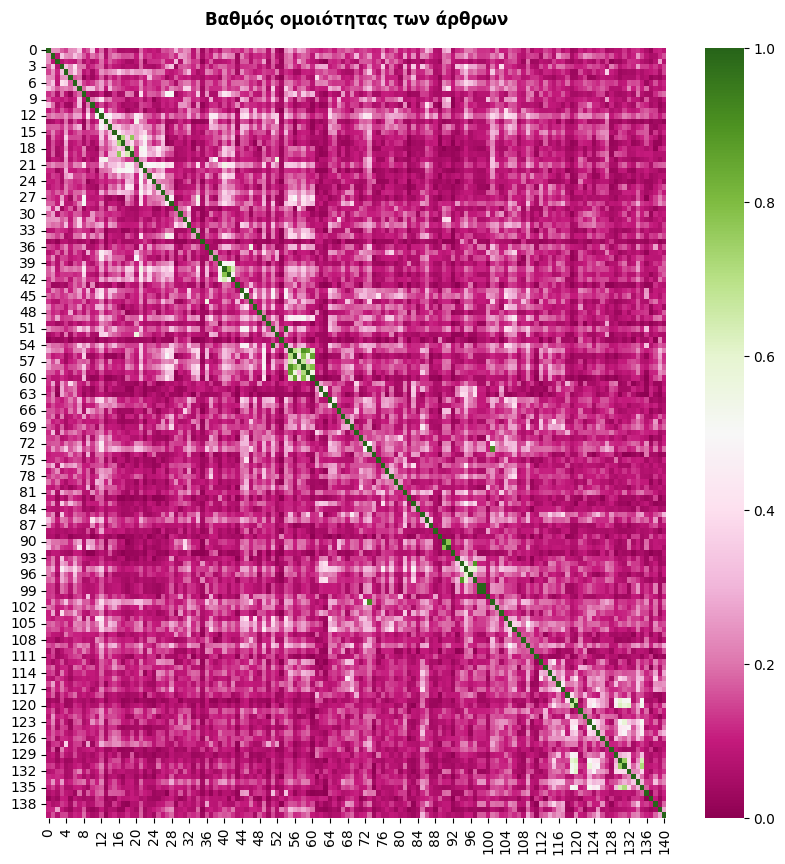

In [ ]:
arr = cosine_similarity(tfidf_matrix_train, tfidf_matrix_train)
plt.figure(figsize=(10, 10))
plt.title('Βαθμός ομοιότητας των άρθρων', y=1.02, fontweight='bold')
sns.heatmap(data=arr, cmap="PiYG")
plt.savefig('Tanea_cosine_similarity_alltexts.png')

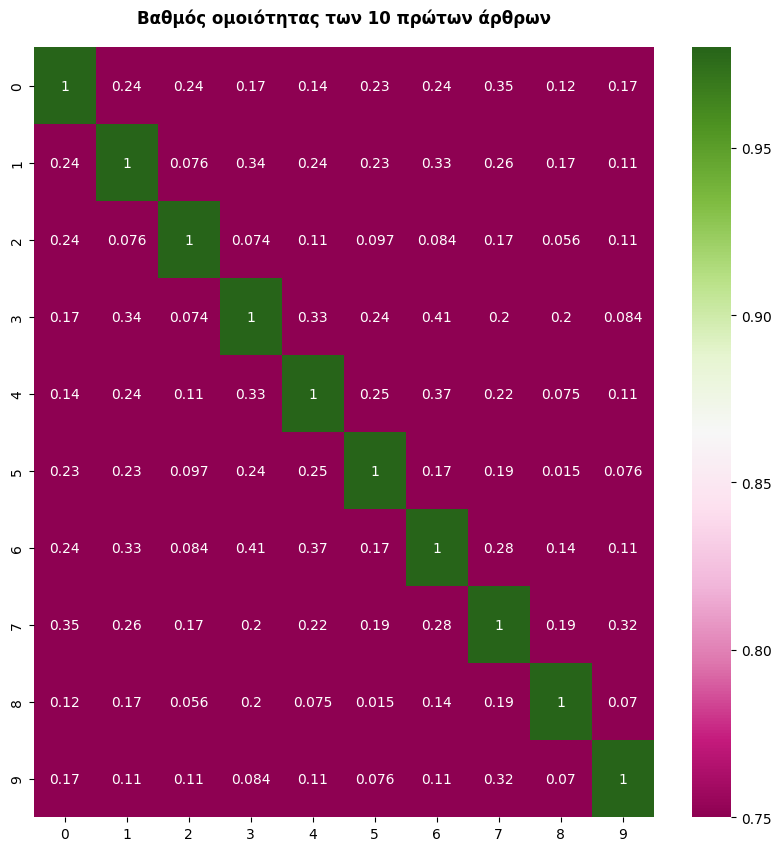

In [ ]:
arr_10 = cosine_similarity(tfidf_matrix_train[0:10], tfidf_matrix_train[0:10])
plt.figure(figsize=(10, 10))
# annot = True to print the values inside the square
plt.title('Βαθμός ομοιότητας των 10 πρώτων άρθρων', y=1.02, fontweight='bold') # το y ορίζει την απόσταση του τίτλου από το γράφημα
sns.heatmap(data=arr_10, annot=True, vmin=0.75, vmax=0.98, cmap="PiYG")
plt.savefig('Tanea_cosine_similarity_10texts.png')


## Εντοπισμός των ζευγαριών άρθρων με τη μεγαλύτερη ομοιότητα (Cosine Similarity)

In [ ]:
# Get the number of articles
num_articles = arr.shape[0]

# Initialize a list to store similarity scores and their corresponding article indices
similarities = []

# Iterate through the upper triangle of the similarity matrix to avoid duplicates and self-similarity
for i in range(num_articles):
    for j in range(i + 1, num_articles):
        similarities.append((arr[i, j], i, j))

# Sort the similarities in descending order
similarities.sort(key=lambda x: x[0], reverse=True)

# Display the top 10 most similar pairs
print("Top 10 Most Similar Article Pairs:")
for sim_score, idx1, idx2 in similarities[:10]:
    print(f"Articles {idx1} and {idx2}: Similarity Score = {sim_score:.4f}")



Top 10 Most Similar Article Pairs:
Articles 98 and 99: Similarity Score = 1.0000
Articles 51 and 54: Similarity Score = 0.9873
Articles 73 and 101: Similarity Score = 0.9132
Articles 55 and 58: Similarity Score = 0.8978
Articles 94 and 97: Similarity Score = 0.8853
Articles 56 and 60: Similarity Score = 0.8571
Articles 55 and 59: Similarity Score = 0.8558
Articles 58 and 60: Similarity Score = 0.7903
Articles 40 and 41: Similarity Score = 0.7835
Articles 56 and 58: Similarity Score = 0.7790


In [ ]:
print("\nFull text of the most similar pair (Articles 0 and 7):")
print(f"Article {similarities[0][1]}:\n{short_tanea_df.loc[similarities[0][1], 'full_text']}\n")
print(f"Article {similarities[0][2]}:\n{short_tanea_df.loc[similarities[0][2], 'full_text']}")


Full text of the most similar pair (Articles 0 and 7):
Article 98:
Ένα λογισμικό παρακολούθησης,δεκάδες παγιδευμένα κινητά, μια σειρά από αναπάντητα γιατί. Το μεγαλύτερο σκάνδαλο τηςΜεταπολίτευσηςεπιστρέφει στο προσκήνιο μέσα από την κάμερα τουMEGA Stories.
ΗΔώρα Αναγνωστοπούλουξετυλίγει το νήμα της υπόθεσης των υποκλοπών, αναζητώντας την αλήθεια πίσω από τις κλειστές πόρτες και τις ηχηρές σιωπές, που ακολούθησαν την πρόσφατη δικαστική απόφαση. Μέσα από τις μαρτυρίες των προσώπων που βρέθηκαν στο επίκεντρο της υπόθεσης, η εκπομπή ανασυνθέτει το χρονικό των παρακολουθήσεων.
Ο δημοσιογράφος Θανάσης Κουκάκης και ο πρόεδρος του ΠΑΣΟΚ-Κινήματος Αλλαγής, Νίκος Ανδρουλάκης –τα δύο θύματα που άνοιξαν τον δρόμο για τη νομική και θεσμική διερεύνηση– περιγράφουν τη στιγμή, που διαπίστωσαν πως βρίσκονταν στο στόχαστρο της ΕΥΠ, καθώς και τον τρόπο με τον οποίο παγιδεύτηκαν οι επικοινωνίες τους μέσω του κακόβουλου λογισμικού Predator.
Στην καθοριστική συμβολή της ερευνητικής δημοσιογραφίας αναφέρετ

In [ ]:
arr = cosine_similarity(tfidf_matrix_train[0:20], tfidf_matrix_train[0:20])

<Axes: title={'center': 'Βαθμός ομοιότητας των 20 πρώτων άρθρων'}>

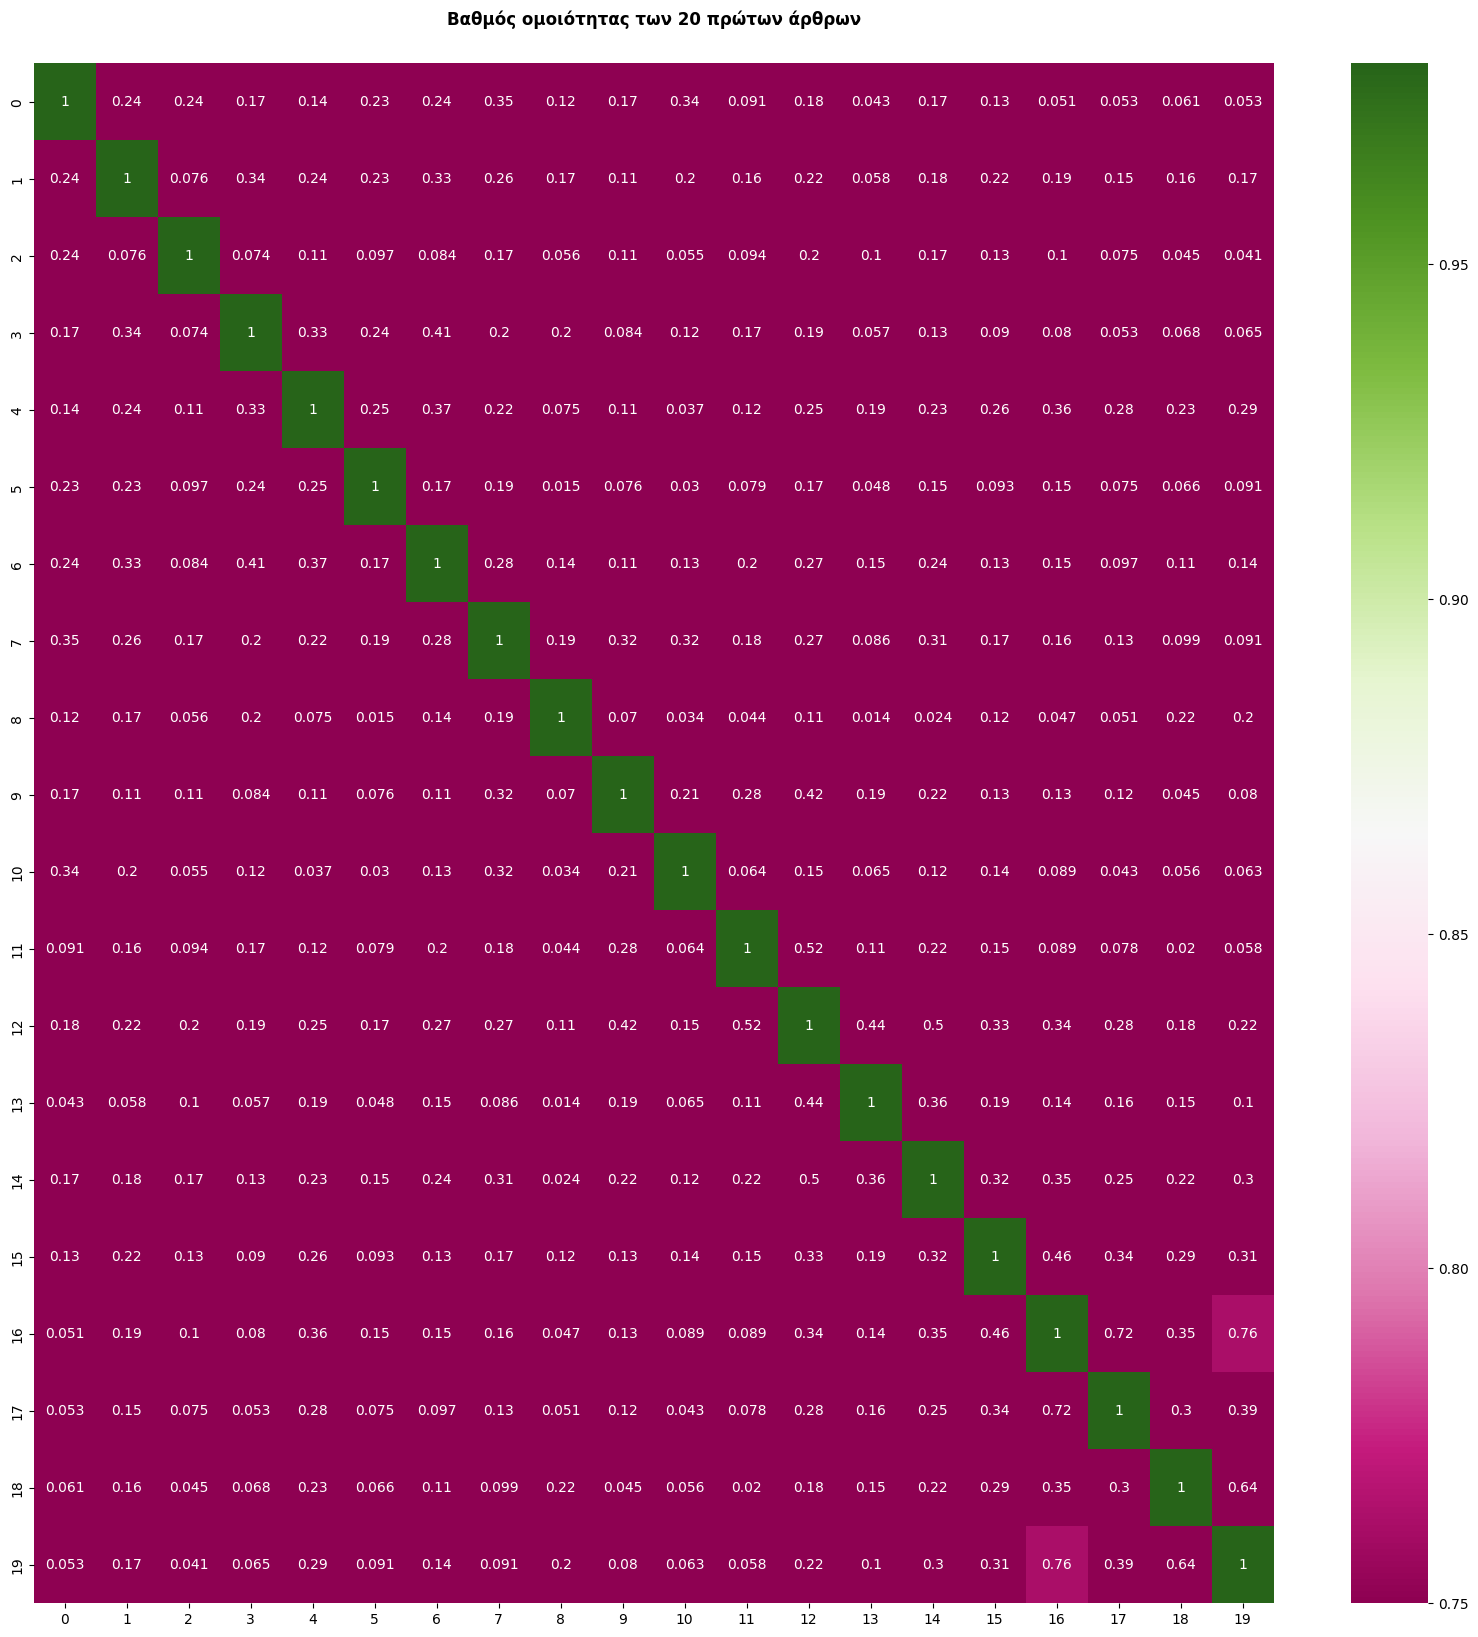

In [ ]:
plt.figure(figsize=(20, 20))
# annot = True to print the values inside the square
plt.title('Βαθμός ομοιότητας των 20 πρώτων άρθρων', y=1.02, fontweight='bold') # το y ορίζει την απόσταση του τίτλου από το γράφημα
sns.heatmap(data=arr, annot=True, vmin=0.75, vmax=0.98, cmap="PiYG")